In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report as cr
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [3]:
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [44]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [7]:
df.shape

(299, 13)

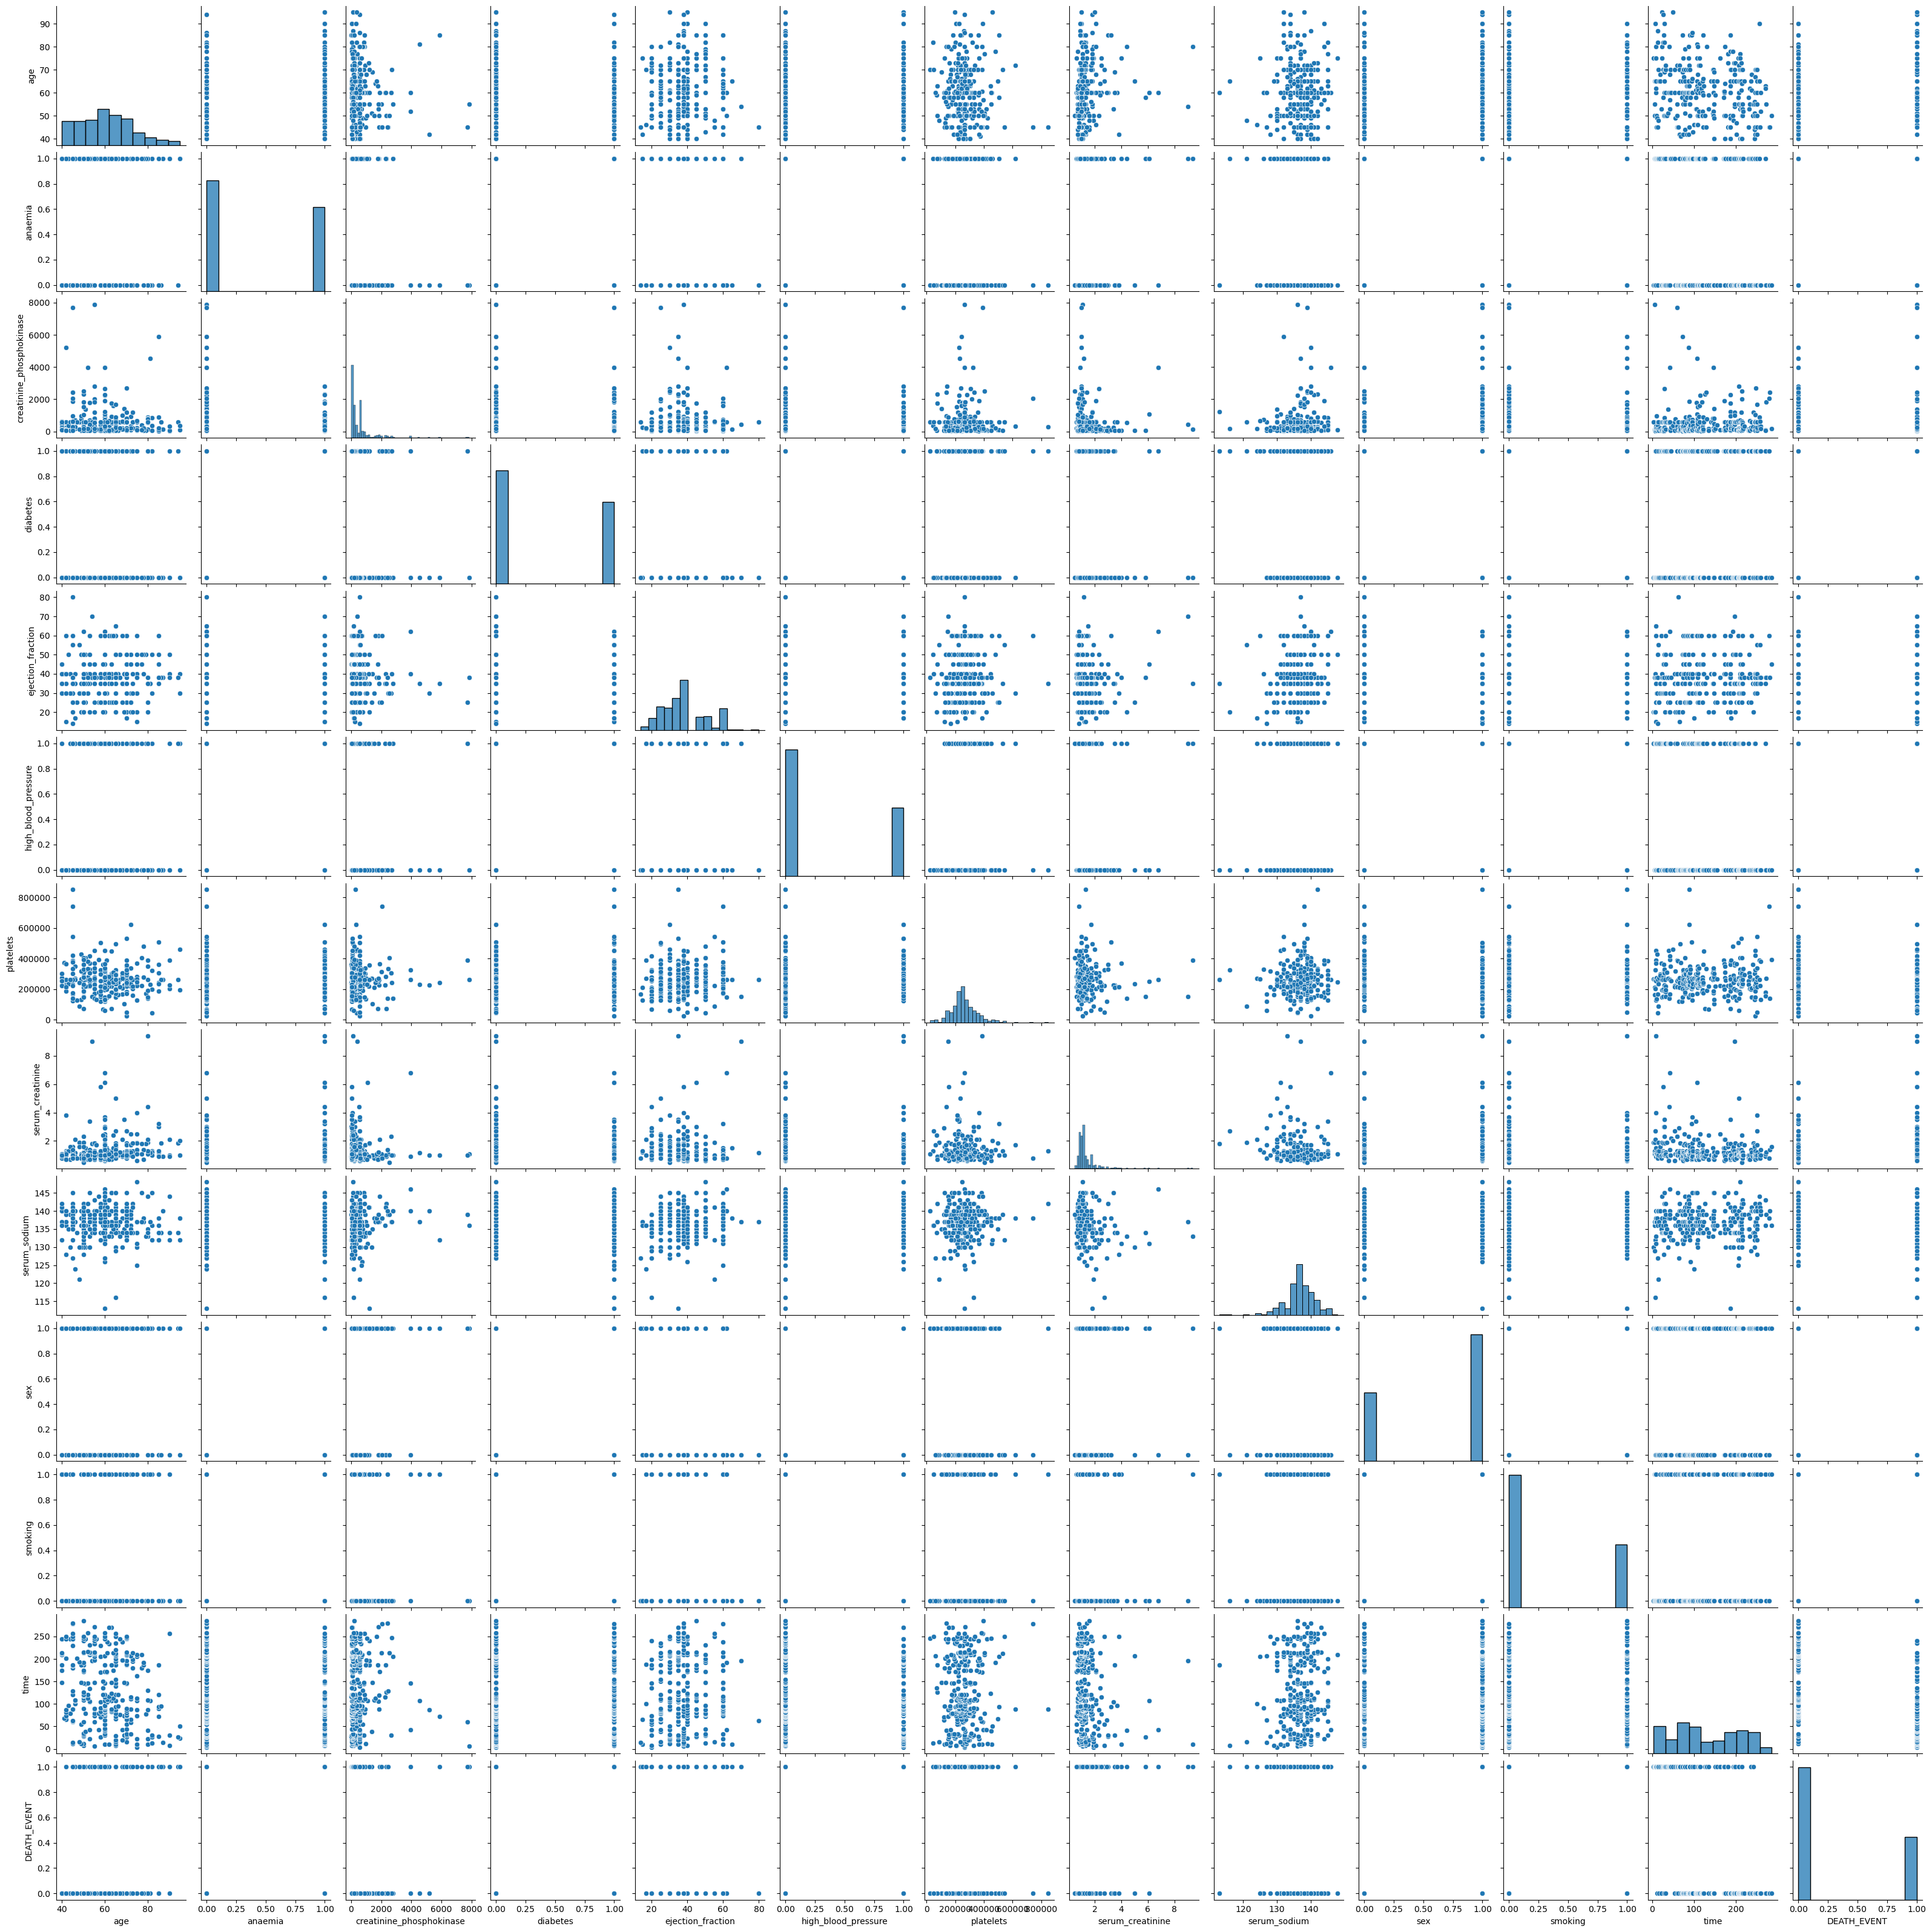

In [22]:
sns.pairplot(df)

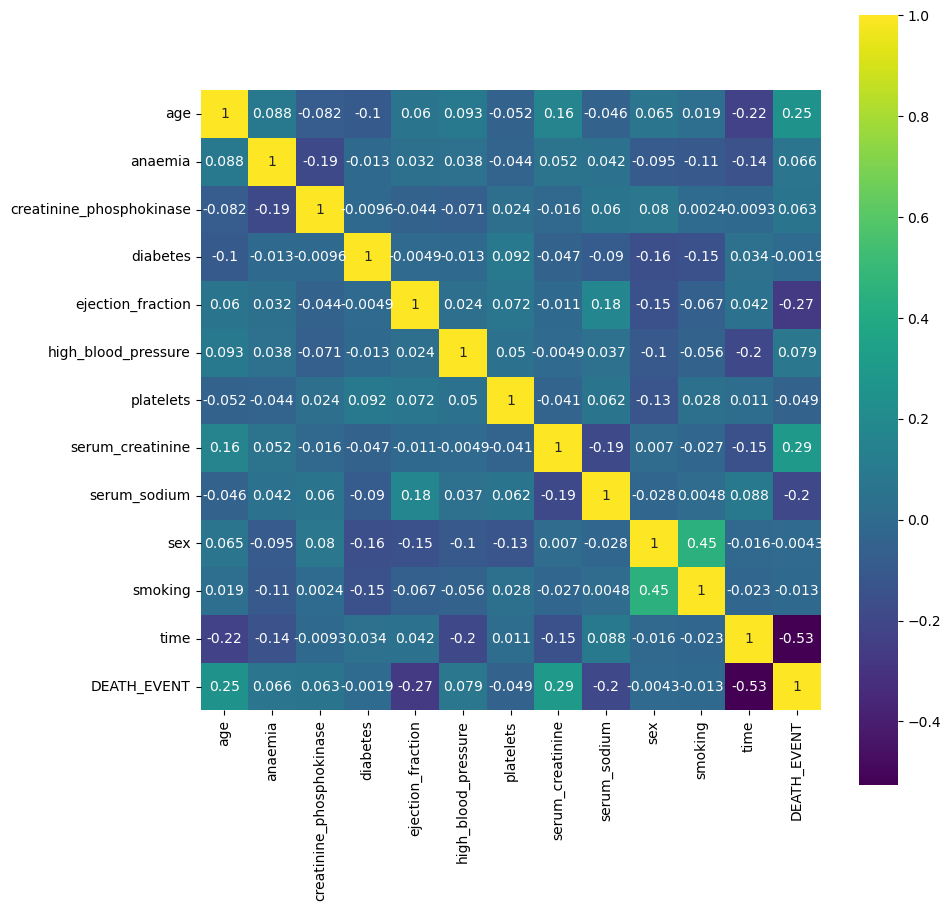

In [28]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(), cmap = 'viridis', annot = True, square = True)
plt.show()

<Axes: >

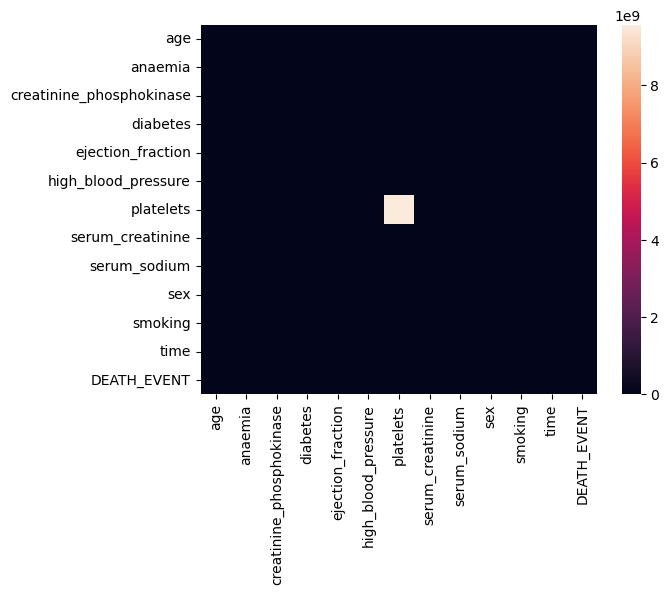

In [11]:
sns.heatmap(df.cov())

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn import svm


<Axes: xlabel='DEATH_EVENT', ylabel='count'>

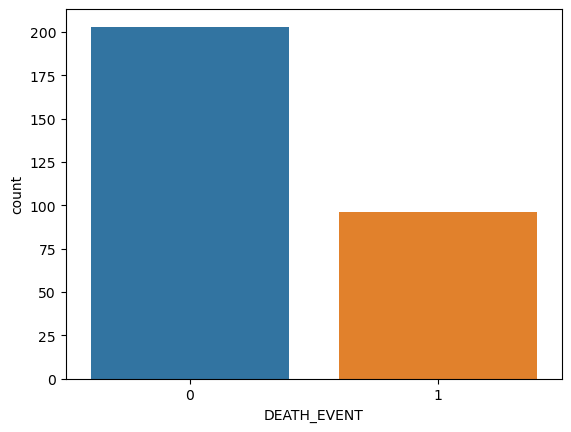

In [20]:
sns.countplot(x=df["DEATH_EVENT"])

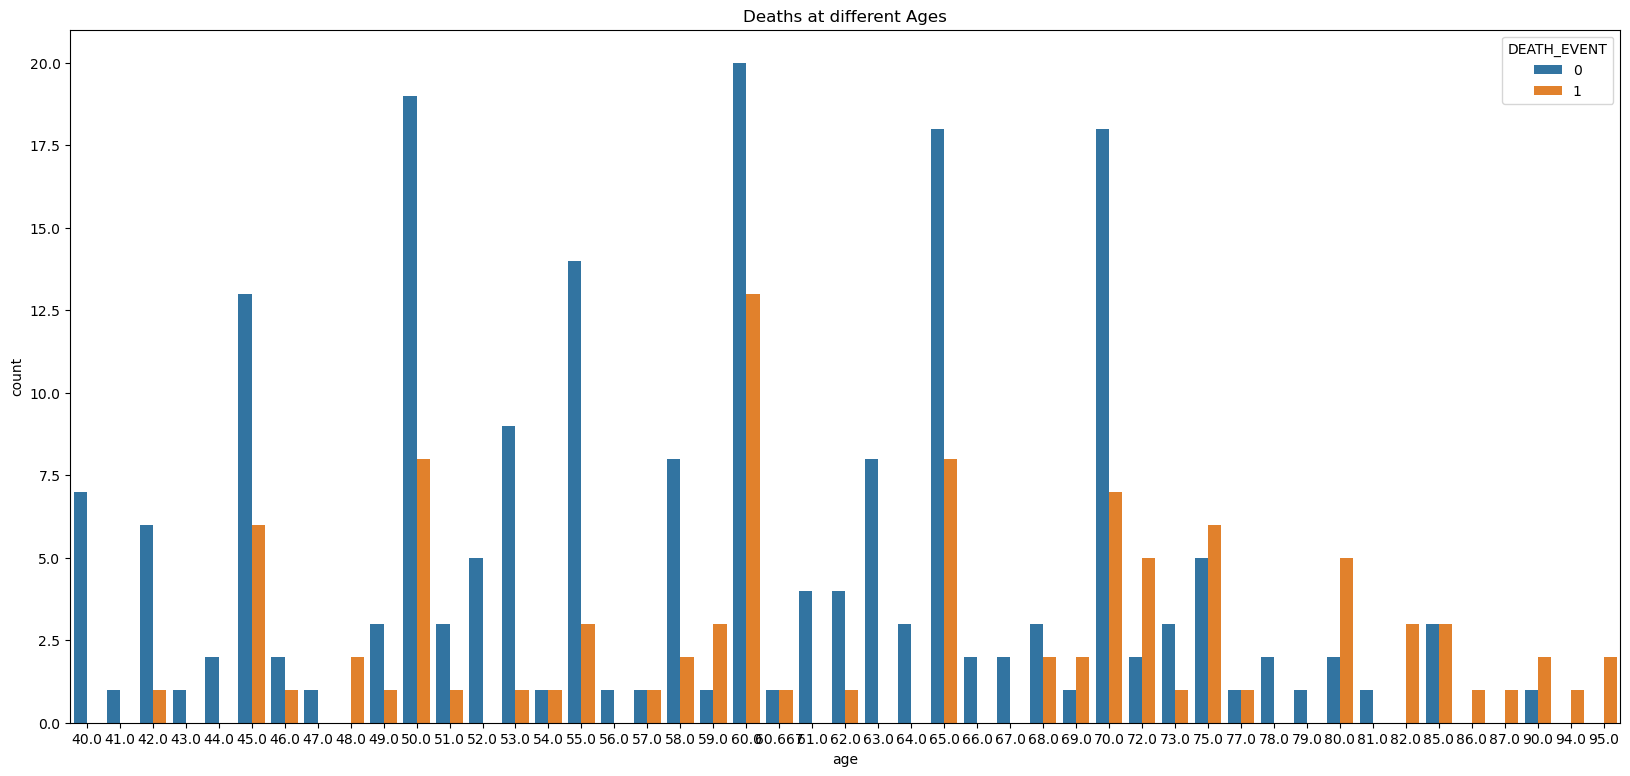

In [31]:
plt.figure(figsize = (20,9))
Distri = sns.countplot(x=df['age'],data=df, hue ="DEATH_EVENT")
plt.title('Deaths at different Ages')
plt.show()

<Axes: xlabel='DEATH_EVENT', ylabel='age'>

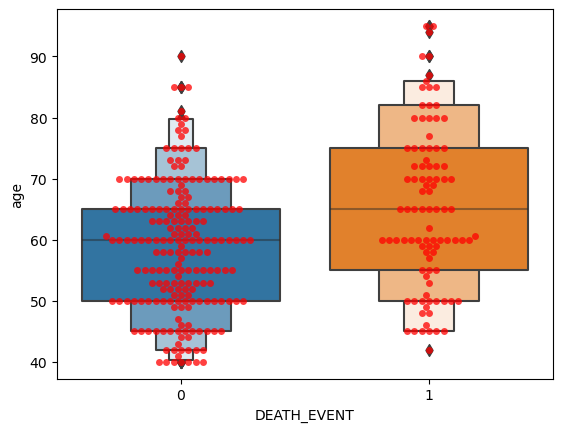

In [40]:
sns.swarmplot(x = df['DEATH_EVENT'], y = df['age'], color = 'red', alpha = 0.75)
sns.boxenplot(x = df['DEATH_EVENT'], y = df['age'])

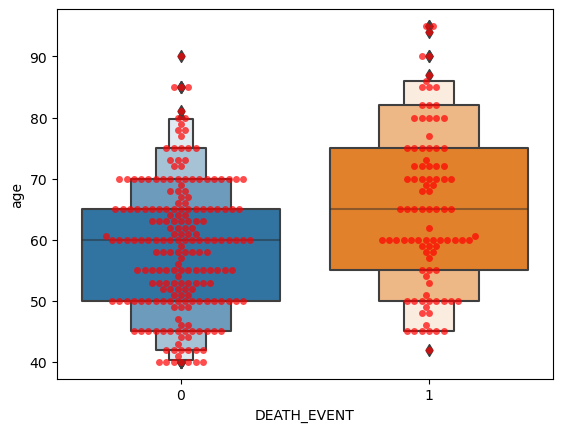

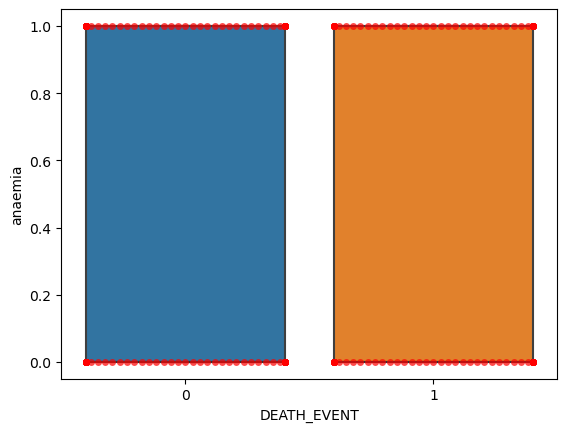

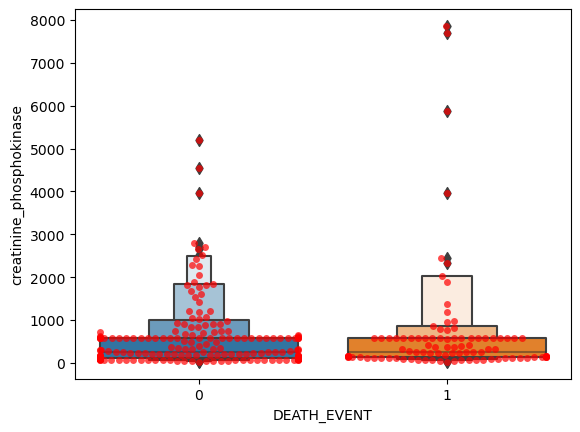

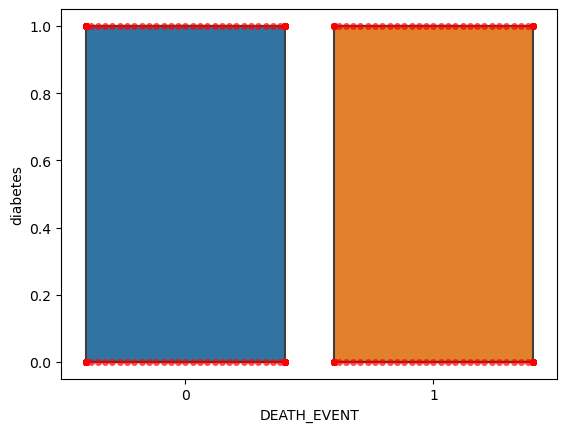

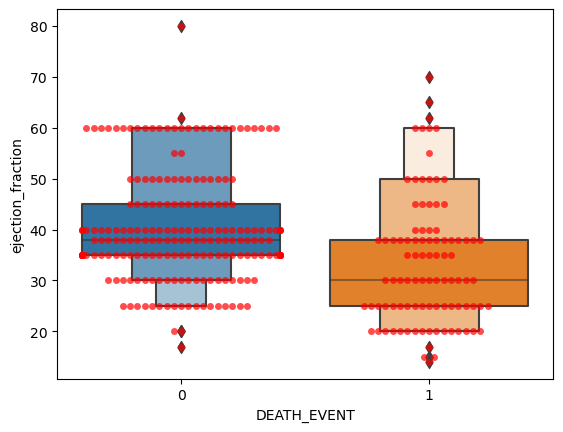

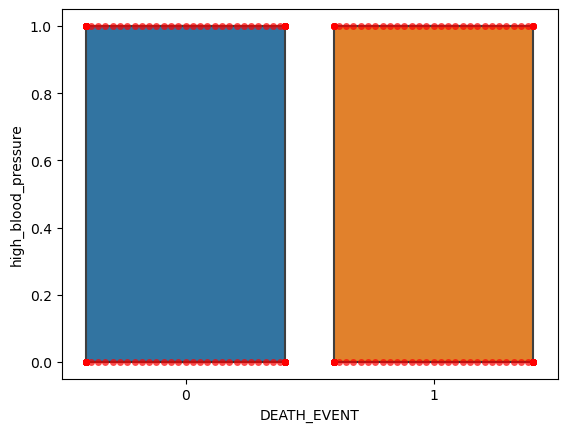

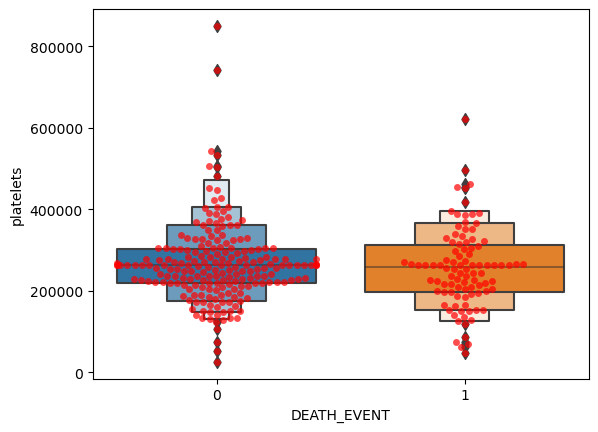

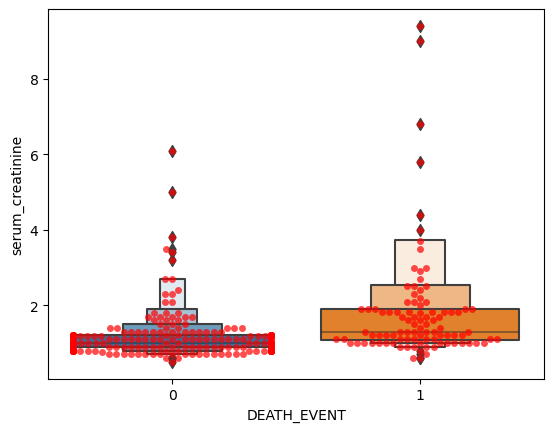

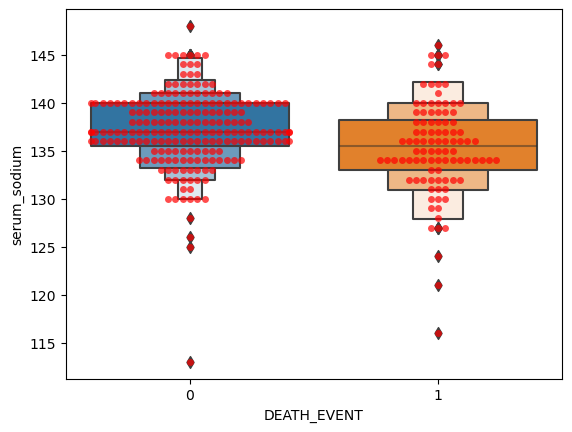

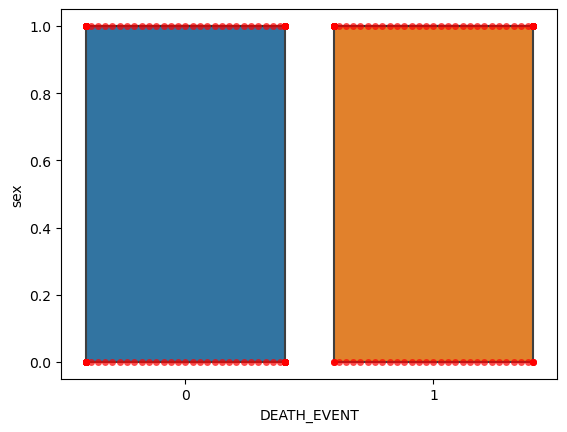

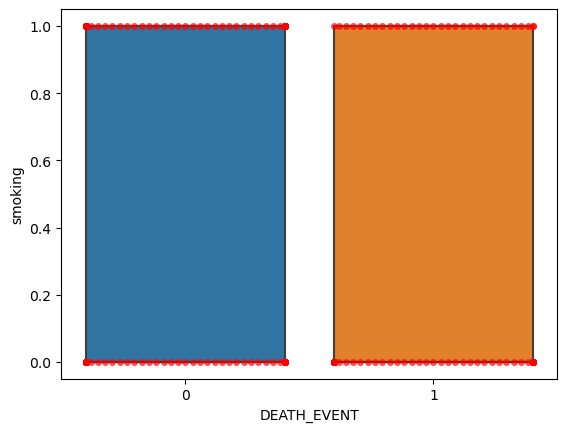

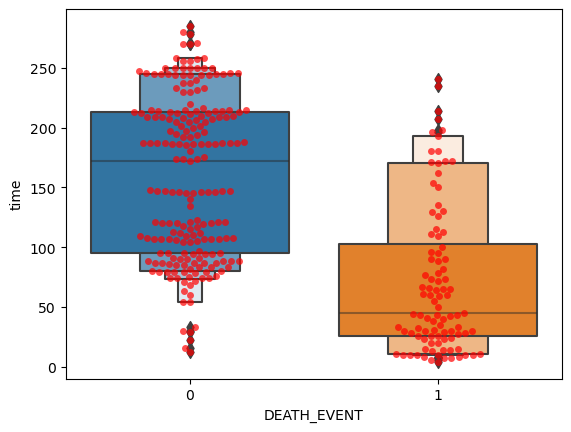

In [51]:
feature = df.columns.drop('DEATH_EVENT')
for i in feature: 
    sns.swarmplot(x=df["DEATH_EVENT"], y=df[i], color="red", alpha=0.7)
    sns.boxenplot(x=df["DEATH_EVENT"], y=df[i])
    plt.show()

In [52]:
x = df.drop('DEATH_EVENT', axis = 1)
y = df['DEATH_EVENT']

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2)

In [59]:
model = svm.SVC().fit(x_train, y_train)
pred = model.predict(x_test)
print('classification report', cr(y_test, pred))

classification report               precision    recall  f1-score   support

           0       0.58      1.00      0.74        35
           1       0.00      0.00      0.00        25

    accuracy                           0.58        60
   macro avg       0.29      0.50      0.37        60
weighted avg       0.34      0.58      0.43        60



In [64]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test, pred)
print(cf_matrix)

[[35  0]
 [25  0]]


<Axes: >

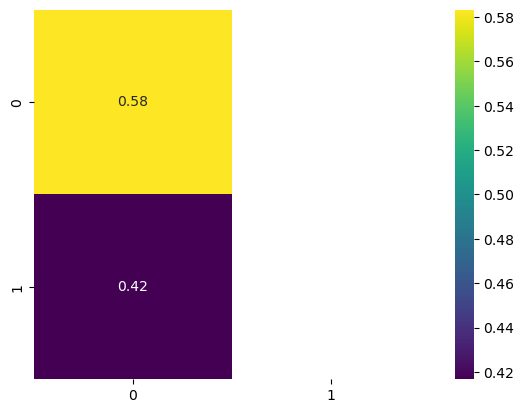

In [67]:
sns.heatmap(cf_matrix/sum(cf_matrix), annot = True, cmap = 'viridis')

In [80]:
svm_model1 = svm.SVC(kernel='linear')
svm_model1.fit(x_train, y_train)

svm_model2 = svm.SVC(kernel='poly')
svm_model2.fit(x_train, y_train)

svm_model3 = svm.SVC(kernel='rbf')
svm_model3.fit(x_train, y_train)

svm_model4 = svm.SVC(kernel='sigmoid')
svm_model4.fit(x_train, y_train)

y_pred1 = svm_model1.predict(x_test)
y_pred2 = svm_model2.predict(x_test)
y_pred3 = svm_model3.predict(x_test)
y_pred4 = svm_model4.predict(x_test)

print('classification report of Kernel:\n', cr(y_test, y_pred1))
print('classification report of Poly:\n', cr(y_test, y_pred2))
print('classification report of RBF:\n', cr(y_test, y_pred3))
print('classification report of Sigmoid:\n', cr(y_test, y_pred4))

classification report of Kernel:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81        35
           1       0.81      0.52      0.63        25

    accuracy                           0.75        60
   macro avg       0.77      0.72      0.72        60
weighted avg       0.76      0.75      0.74        60

classification report of Poly:
               precision    recall  f1-score   support

           0       0.58      1.00      0.74        35
           1       0.00      0.00      0.00        25

    accuracy                           0.58        60
   macro avg       0.29      0.50      0.37        60
weighted avg       0.34      0.58      0.43        60

classification report of RBF:
               precision    recall  f1-score   support

           0       0.58      1.00      0.74        35
           1       0.00      0.00      0.00        25

    accuracy                           0.58        60
   macro avg       0.29      0.

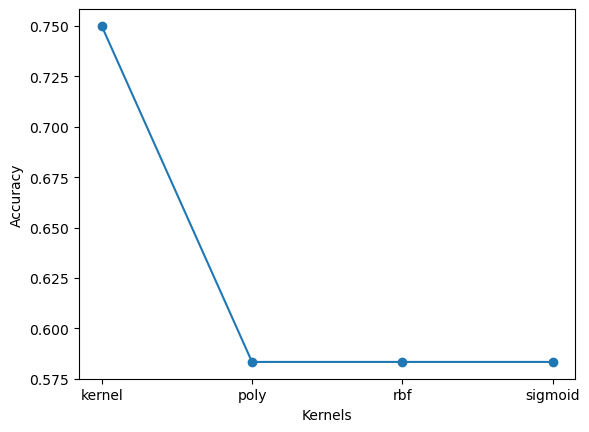

In [85]:
from sklearn.metrics import accuracy_score as a_s
methods = ['kernel', 'poly', 'rbf', 'sigmoid']
accuracy = [ a_s(y_test, y_pred1), a_s(y_test, y_pred2), a_s(y_test, y_pred3), a_s(y_test, y_pred4)]
plt.plot(methods, accuracy, marker = 'o')
plt.xlabel('Kernels')
plt.ylabel('Accuracy')
plt.show()

In [89]:
X = df[['age', 'diabetes']]
y = df['DEATH_EVENT']
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

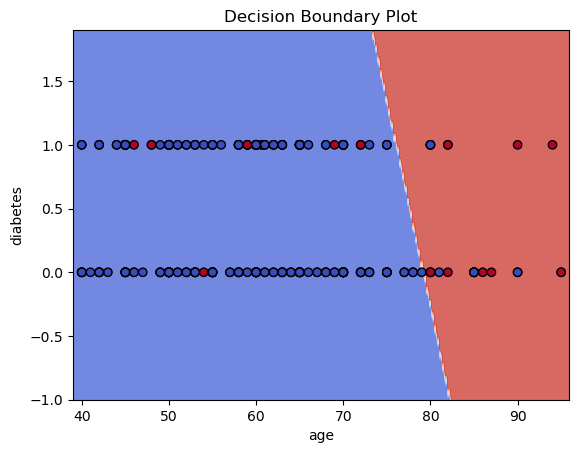

In [92]:
x_min, x_max = X['age'].min() - 1, X['age'].max() + 1
y_min, y_max = X['diabetes'].min() - 1, X['diabetes'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.get_cmap('coolwarm'))
plt.scatter(X['age'], X['diabetes'], c=y_encoded, edgecolors='k', marker='o', cmap=plt.get_cmap('coolwarm'))
plt.xlabel('age')
plt.ylabel('diabetes')
plt.title('Decision Boundary Plot')
plt.show()